# Supermarket Campaign Analysis

#### This project is to show you just some of the things that we can do with ml in order to garner insights about our customers and whatnot, this specific dataset is related to a supermarket and am not sure how similar the data will be to what facebook provides but it's still something similar and an indication of some of the things we can do, of course this is just scraping the surface of some of the data we could leverage and how we can optimize how we run ads and what kind of info we are using to make our decisions

#### PS not entirely sure if you will be able to run all these cells of code since you would need to download the dataset etc but I think all the outputs should be there, I could have done more analysis however I thought this was sufficient and we can always do more in depth things in the future that are more company specific plus I am still researching about this topic but found that my data analysis background translates a lot, also the formatting is likely not the best but hopefully you get the idea

A customer lifecyle focuses on Reach, Acquisition, Engagement, Growth and finally retention, I'm going to focus on the growth phase where using the past marketing campaigns we are going to make a machine learning and use the insights for our future campaigns, this would probably be pretty useful for Cafe liegois

Now this DataSet provides the Spend & Engagement, Demographics (education, marital status etc, Campaign Responses (response to the last campaign, offere acceptance from first 5 campaigns
if the offer was accepted in the campaign it will be represented by a 1, wont go too into detail but thats a rough look of this dataset so that you can understand the features I've got
in order to leverage the insights that I came too.

## Importing the Libraries

In [ ]:
%pip install seaborn matplotlib


In [ ]:
%pip install openpyxl

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the Data

In [ ]:
df = pd.read_excel("marketing_campaign.xlsx")

In [ ]:
df.shape

(2240, 29)

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

## Moving onto some of the Data Preprocessing

#### Drop the ID feature since it is not necessary

In [ ]:
df = df.drop(['ID'],axis = 1)

In [ ]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


### Let's set the Target and Independent Features

In [ ]:
type(df['Response'])

pandas.core.series.Series

In [ ]:
Y =df[['Response']]
X =df.drop(['Response'],axis = 1)

In [ ]:
Y.mean()

Response    0.149107
dtype: float64

so based on this dataset about 15% of the customers are actually responding to the marketing campaigns right now

### Ok Now I am going to be trying to determine some possible similar features and how we can reduce the amount of info we have into more actionable things

#### Customer Age and Tenure

In [ ]:
import datetime
reference_date = datetime.datetime(2026,4,12)
print(reference_date)

2026-04-12 00:00:00


In [ ]:
# Convert to datetime
X['Year_Birth'] = pd.to_datetime(df['Year_Birth'], format='%Y')
X['Dt_Customer'] = pd.to_datetime(X['Dt_Customer'])

# Calculate Age (Difference in days divided by 365.25)
X['Age'] = (reference_date - X['Year_Birth']).dt.days // 365.25

# Calculate Tenure (Difference in days divided by 365.25)
X['Cust_Tenure'] = (reference_date - X['Dt_Customer']).dt.days // 365.25

# Drop the original date columns
X = X.drop(['Year_Birth', 'Dt_Customer'], axis=1)

In [ ]:
X

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Age,Cust_Tenure
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,69.0,13.0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,72.0,12.0
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,61.0,12.0
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,42.0,12.0
4,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,45.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,59.0,12.0
2236,PhD,Together,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,80.0,11.0
2237,Graduation,Divorced,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,45.0,12.0
2238,Master,Together,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,70.0,12.0


In [ ]:
X[['Age','Cust_Tenure']].head()

,Age,Cust_Tenure
0,69.0,13.0
1,72.0,12.0
2,61.0,12.0
3,42.0,12.0
4,45.0,12.0


#### Split features into numerical and Categorical data

In [ ]:
num = X.select_dtypes(include = ['number']).columns.tolist()

cat = X.select_dtypes(include = ['object', 'category']).columns.tolist()

print(f"Numerical features ({len(num)}): {num}")
print(f"Categorical features ({len(cat)}): {cat}")

Numerical features (25): ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Age', 'Cust_Tenure']
Categorical features (2): ['Education', 'Marital_Status']


#### create a df for each

In [ ]:
X_num = X[num]
X_cat = X[cat]

In [ ]:
X_num

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Age,Cust_Tenure
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,69.0,13.0
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,72.0,12.0
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,61.0,12.0
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,42.0,12.0
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,45.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,59.0,12.0
2236,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,80.0,11.0
2237,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,45.0,12.0
2238,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,70.0,12.0


#### ok well this did not exactly split them correctly since some of these columns are clearly categorical so I will need to look at unique vals in order to find out which ones are actually categorical and add them to the other X_cat

In [ ]:
# Check the number of unique values in just the numerical columns
# Sorting them helps you spot the low-cardinality (likely categorical) ones instantly
unique_counts = X[num].nunique().sort_values()

print("Unique values in numerical columns:")
print(unique_counts)
print((unique_counts[unique_counts < 20]))

Unique values in numerical columns:
Z_Revenue                 1
Z_CostContact             1
Complain                  2
AcceptedCmp2              2
AcceptedCmp1              2
AcceptedCmp5              2
AcceptedCmp4              2
AcceptedCmp3              2
Cust_Tenure               3
Kidhome                   3
Teenhome                  3
NumStorePurchases        14
NumCatalogPurchases      14
NumWebPurchases          15
NumDealsPurchases        15
NumWebVisitsMonth        16
Age                      59
Recency                 100
MntFruits               158
MntSweetProducts        177
MntFishProducts         182
MntGoldProds            213
MntMeatProducts         558
MntWines                776
Income                 1974
dtype: int64
Z_Revenue               1
Z_CostContact           1
Complain                2
AcceptedCmp2            2
AcceptedCmp1            2
AcceptedCmp5            2
AcceptedCmp4            2
AcceptedCmp3            2
Cust_Tenure             3
Kidhome          

In [ ]:
# Filter for columns with 20 or fewer unique values
cols_to_copy = unique_counts[unique_counts <= 20].index.tolist()

# Print the final list
print(cols_to_copy)

['Z_Revenue', 'Z_CostContact', 'Complain', 'AcceptedCmp2', 'AcceptedCmp1', 'AcceptedCmp5', 'AcceptedCmp4', 'AcceptedCmp3', 'Cust_Tenure', 'Kidhome', 'Teenhome', 'NumStorePurchases', 'NumCatalogPurchases', 'NumWebPurchases', 'NumDealsPurchases', 'NumWebVisitsMonth']


In [ ]:
misclassified_cols = ['Z_Revenue', 'Z_CostContact', 'Complain', 'AcceptedCmp2', 'AcceptedCmp1', 'AcceptedCmp5', 'AcceptedCmp4', 'AcceptedCmp3', 'Kidhome', 'Teenhome']

In [ ]:
# change datatype to object
X[misclassified_cols] = X[misclassified_cols].astype('object')

# resplit it
X_num = X.select_dtypes(include=['number'])
X_cat = X.select_dtypes(include=['object', 'category'])

# Verify the final split
print(f"Final Numerical features: {X_num.shape[1]}")
print(f"Final Categorical features: {X_cat.shape[1]}")

Final Numerical features: 15
Final Categorical features: 12


In [ ]:
X_num

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Cust_Tenure
0,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,69.0,13.0
1,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,72.0,12.0
2,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,61.0,12.0
3,26646.0,26,11,4,20,10,3,5,2,2,0,4,6,42.0,12.0
4,58293.0,94,173,43,118,46,27,15,5,5,3,6,5,45.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,709,43,182,42,118,247,2,9,3,4,5,59.0,12.0
2236,64014.0,56,406,0,30,0,0,8,7,8,2,5,7,80.0,11.0
2237,56981.0,91,908,48,217,32,12,24,1,2,3,13,6,45.0,12.0
2238,69245.0,8,428,30,214,80,30,61,2,6,5,10,3,70.0,12.0


In [ ]:
X_cat

,Education,Marital_Status,Kidhome,Teenhome,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
0,Graduation,Single,0,0,0,0,0,0,0,0,3,11
1,Graduation,Single,1,1,0,0,0,0,0,0,3,11
2,Graduation,Together,0,0,0,0,0,0,0,0,3,11
3,Graduation,Together,1,0,0,0,0,0,0,0,3,11
4,PhD,Married,1,0,0,0,0,0,0,0,3,11
...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,0,1,0,0,0,0,0,0,3,11
2236,PhD,Together,2,1,0,0,0,1,0,0,3,11
2237,Graduation,Divorced,0,0,0,1,0,0,0,0,3,11
2238,Master,Together,0,1,0,0,0,0,0,0,3,11


there may be some more stuff I can do but I think this should be sufficient

### Data Cleaning

In [ ]:
X_num.describe(percentiles = [0.01,0.05,0.10,0.25,0.50,0.75,0.85,0.9,0.99])

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Cust_Tenure
count,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52247.251354,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,57.194196,12.263839
std,25173.076661,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,11.984069,0.642082
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,11.000000
1%,7579.200000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,34.000000,11.000000
5%,18985.500000,4.000000,3.000000,0.000000,4.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,2.000000,1.000000,38.000000,11.000000
10%,24117.500000,9.000000,6.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,2.000000,2.000000,42.000000,11.000000
25%,35303.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,49.000000,12.000000
50%,51381.500000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,56.000000,12.000000
75%,68522.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,67.000000,13.000000


### Let's do some capping and flooring for outliers

get's rid of extremem vals since they might not represent the majority of people

In [ ]:
def outlier_cap(x):
    x =x.clip(lower = x.quantile(0.01))
    x = x.clip(upper = x.quantile(0.99))
    return(x)

In [ ]:
X_num = X_num.apply(lambda x : outlier_cap(x))

In [ ]:
X_num.describe(percentiles = [0.01,0.05,0.10,0.25,0.50,0.75,0.85,0.9,0.99])

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Cust_Tenure
count,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,51770.277076,49.101786,302.909821,26.158482,165.075446,37.351366,26.873687,43.770089,2.299554,4.058929,2.630371,5.806696,5.286607,57.132143,12.263839
std,20728.704775,28.949501,333.316827,39.208270,216.547373,53.985910,40.484302,51.118104,1.800700,2.642307,2.752313,3.226959,2.296277,11.666094,0.642082
min,7579.200000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,34.000000,11.000000
1%,7646.520000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,34.000000,11.000000
5%,18985.500000,4.000000,3.000000,0.000000,4.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,2.000000,1.000000,38.000000,11.000000
10%,24117.500000,9.000000,6.000000,0.000000,7.000000,0.000000,0.000000,3.000000,1.000000,1.000000,0.000000,2.000000,2.000000,42.000000,11.000000
25%,35303.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,49.000000,12.000000
50%,51381.500000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,56.000000,12.000000
75%,68522.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,67.000000,13.000000


### Missing val

In [ ]:
X_num.isnull().mean()

Income                 0.010714
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
Age                    0.000000
Cust_Tenure            0.000000
dtype: float64

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
num_1 = pd.DataFrame(imputer.fit_transform(X_num),index = X_num.index,columns = X_num.columns)

In [ ]:
num_1.isnull().mean()

Income                 0.0
Recency                0.0
MntWines               0.0
MntFruits              0.0
MntMeatProducts        0.0
MntFishProducts        0.0
MntSweetProducts       0.0
MntGoldProds           0.0
NumDealsPurchases      0.0
NumWebPurchases        0.0
NumCatalogPurchases    0.0
NumStorePurchases      0.0
NumWebVisitsMonth      0.0
Age                    0.0
Cust_Tenure            0.0
dtype: float64

In [ ]:
num_1

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Cust_Tenure
0,58138.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,3.0,8.0,10.0,4.0,7.0,69.0,13.0
1,46344.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,1.0,2.0,5.0,72.0,12.0
2,71613.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,2.0,10.0,4.0,61.0,12.0
3,26646.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,0.0,4.0,6.0,42.0,12.0
4,58293.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,3.0,6.0,5.0,45.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46.0,709.0,43.0,182.0,42.0,118.0,227.0,2.0,9.0,3.0,4.0,5.0,59.0,12.0
2236,64014.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,7.0,8.0,2.0,5.0,7.0,80.0,11.0
2237,56981.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,1.0,2.0,3.0,13.0,6.0,45.0,12.0
2238,69245.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,2.0,6.0,5.0,10.0,3.0,70.0,12.0


In [ ]:
X_cat.isnull().mean()

Education         0.0
Marital_Status    0.0
Kidhome           0.0
Teenhome          0.0
AcceptedCmp3      0.0
AcceptedCmp4      0.0
AcceptedCmp5      0.0
AcceptedCmp1      0.0
AcceptedCmp2      0.0
Complain          0.0
Z_CostContact     0.0
Z_Revenue         0.0
dtype: float64

no missing vals so no need to deal with missing vals

## Feature Selection

#### Remove features with 0 variance

In [ ]:
from sklearn.feature_selection import VarianceThreshold

varselector= VarianceThreshold(threshold=0)
varselector.fit_transform(num_1)
# Get columns to keep and create new dataframe with those only
cols = varselector.get_support(indices=True)
num_2 = num_1.iloc[:,cols]

In [ ]:
num_2.iloc[0]

Income                 58138.0
Recency                   58.0
MntWines                 635.0
MntFruits                 88.0
MntMeatProducts          546.0
MntFishProducts          172.0
MntSweetProducts          88.0
MntGoldProds              88.0
NumDealsPurchases          3.0
NumWebPurchases            8.0
NumCatalogPurchases       10.0
NumStorePurchases          4.0
NumWebVisitsMonth          7.0
Age                       69.0
Cust_Tenure               13.0
Name: 0, dtype: float64

### Bi Variate Analysis (Feature Discretization)

This is usefule in order to find the most useful features, catch redundancy and to spot any hidden outliers

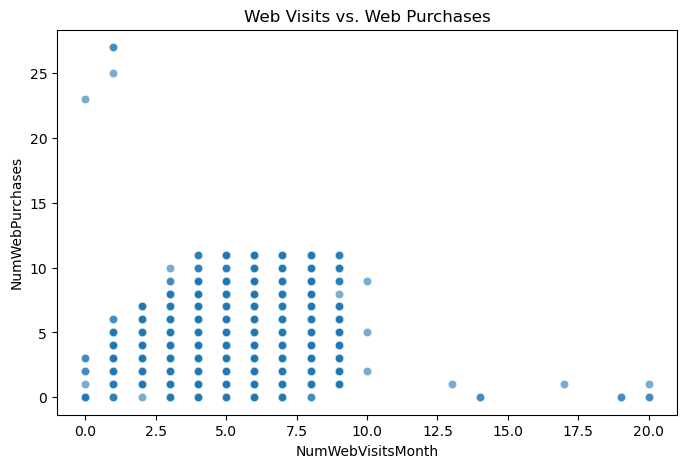

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Plotting visits vs purchases
sns.scatterplot(data=X, x='NumWebVisitsMonth', y='NumWebPurchases', alpha=0.6)

plt.title('Web Visits vs. Web Purchases')
plt.show()

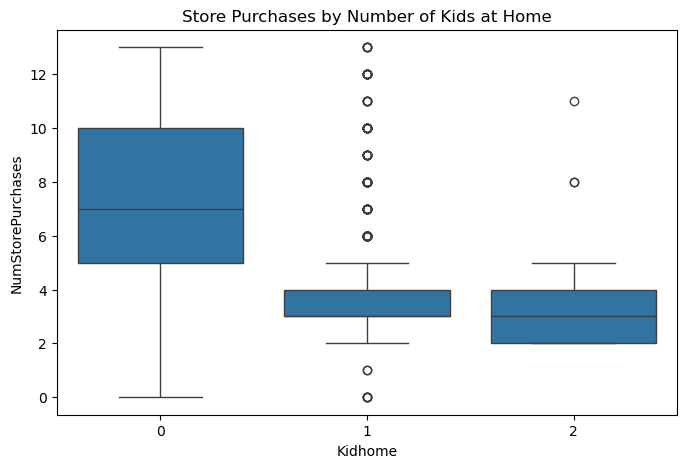

In [ ]:
plt.figure(figsize=(8, 5))
# x is the category (Kidhome), y is the number (Store Purchases)
sns.boxplot(data=X, x='Kidhome', y='NumStorePurchases')

plt.title('Store Purchases by Number of Kids at Home')
plt.show()

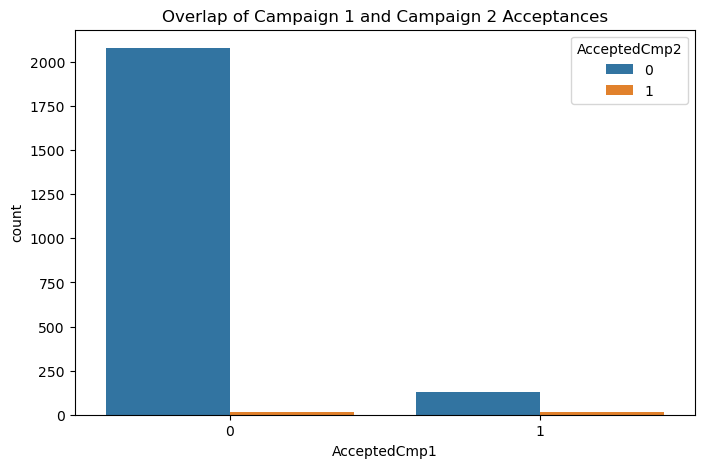

In [ ]:
plt.figure(figsize=(8, 5))
# x is the first category, 'hue' colors the bars by the second category
sns.countplot(data=X, x='AcceptedCmp1', hue='AcceptedCmp2')

plt.title('Overlap of Campaign 1 and Campaign 2 Acceptances')
plt.show()

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
discrete=KBinsDiscretizer(n_bins=10,encode='ordinal', strategy='quantile')
num_binned=pd.DataFrame(discrete.fit_transform(num_2),index=num_2.index, columns=num_2.columns).add_suffix('_Rank')
num_binned.head()

,Income_Rank,Recency_Rank,MntWines_Rank,MntFruits_Rank,MntMeatProducts_Rank,MntFishProducts_Rank,MntSweetProducts_Rank,MntGoldProds_Rank,NumDealsPurchases_Rank,NumWebPurchases_Rank,NumCatalogPurchases_Rank,NumStorePurchases_Rank,NumWebVisitsMonth_Rank,Age_Rank,Cust_Tenure_Rank
0,5.0,5.0,8.0,8.0,9.0,8.0,7.0,8.0,3.0,7.0,5.0,2.0,6.0,8.0,1.0
1,4.0,3.0,1.0,1.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,0.0,4.0,8.0,1.0
2,7.0,2.0,7.0,7.0,6.0,7.0,5.0,6.0,1.0,7.0,2.0,6.0,3.0,6.0,1.0
3,1.0,2.0,1.0,3.0,3.0,3.0,2.0,1.0,2.0,2.0,0.0,2.0,5.0,1.0,1.0
4,6.0,9.0,4.0,6.0,6.0,6.0,6.0,3.0,4.0,5.0,2.0,4.0,4.0,1.0,1.0


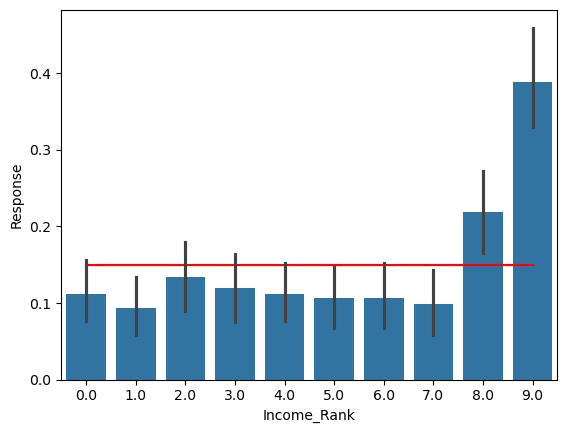

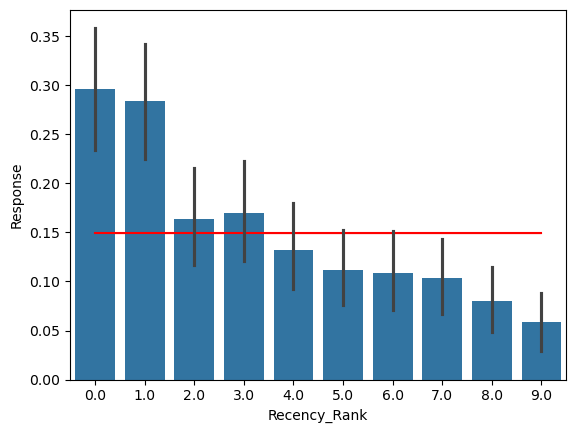

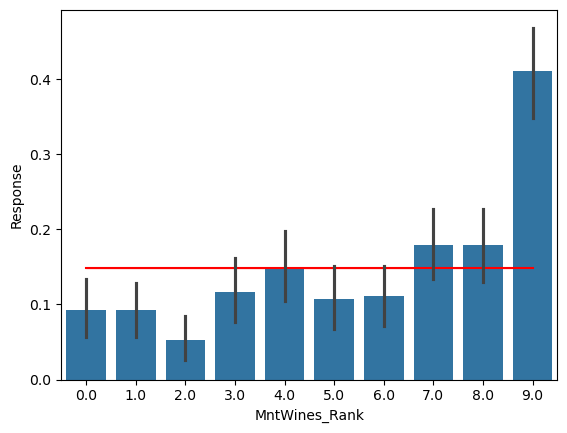

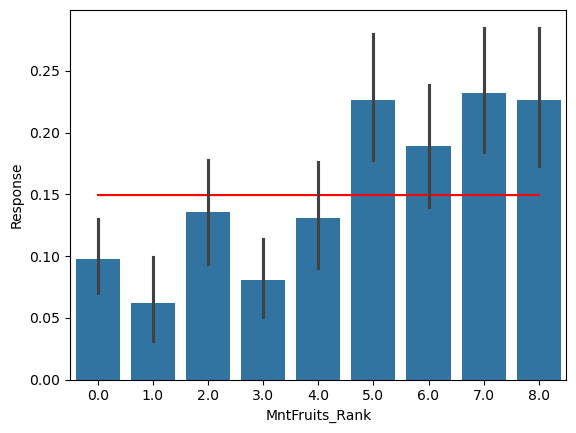

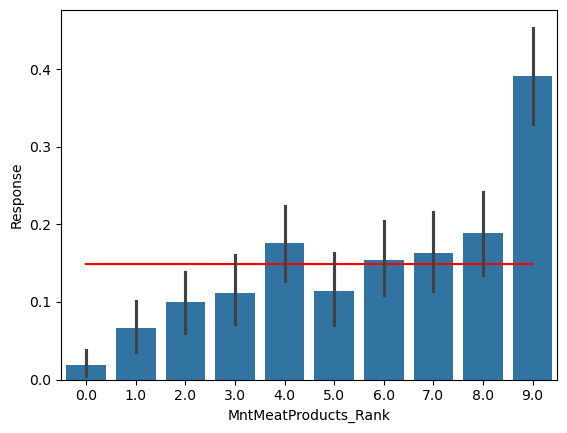

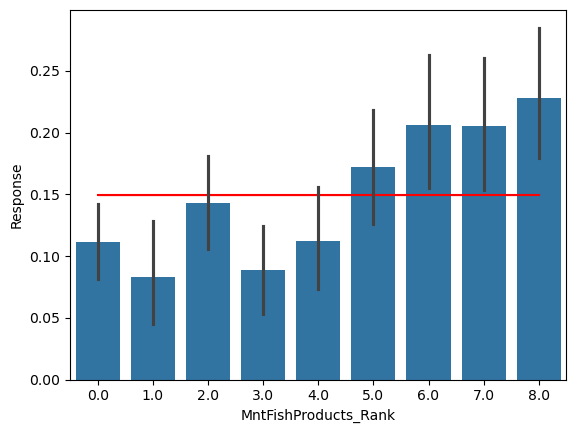

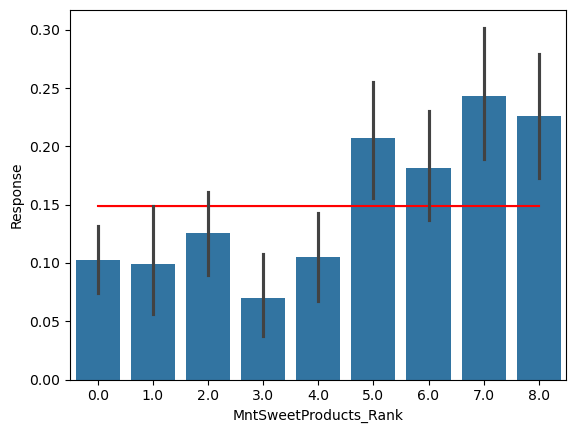

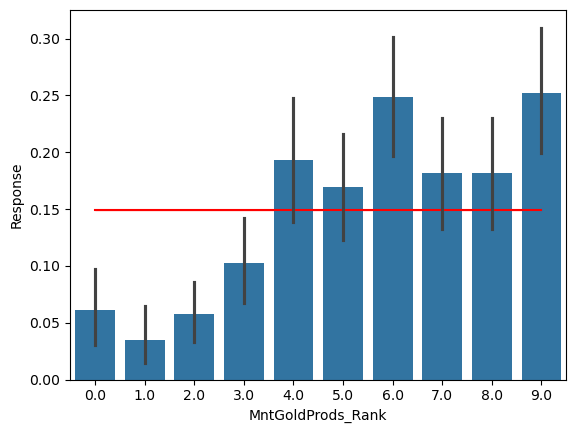

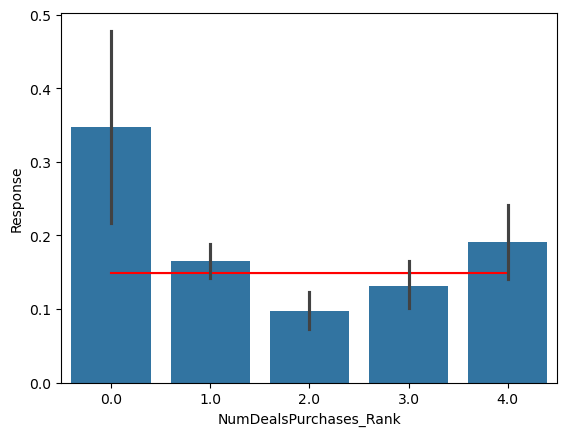

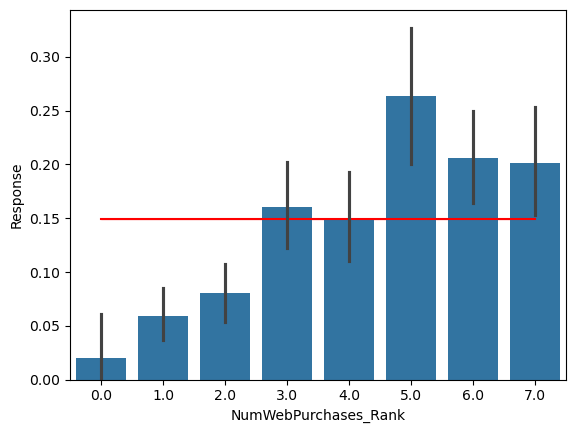

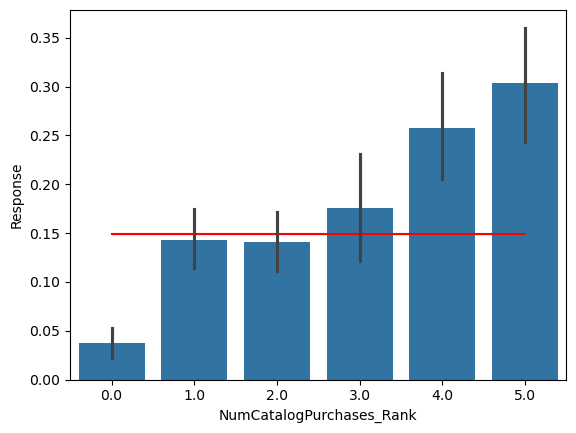

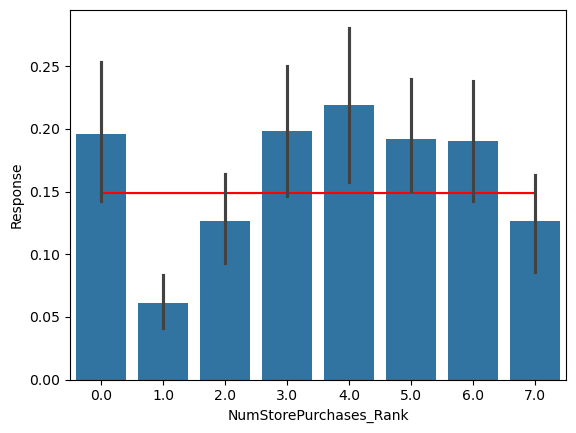

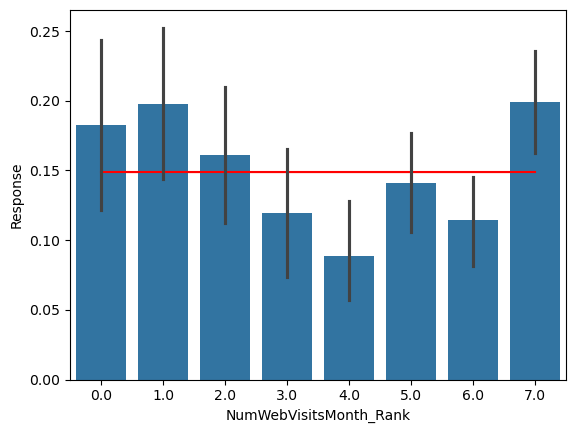

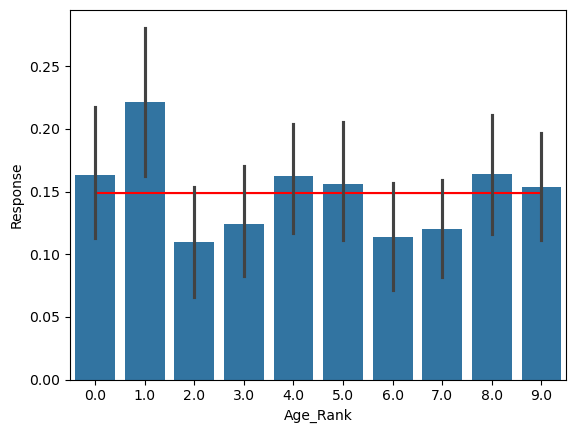

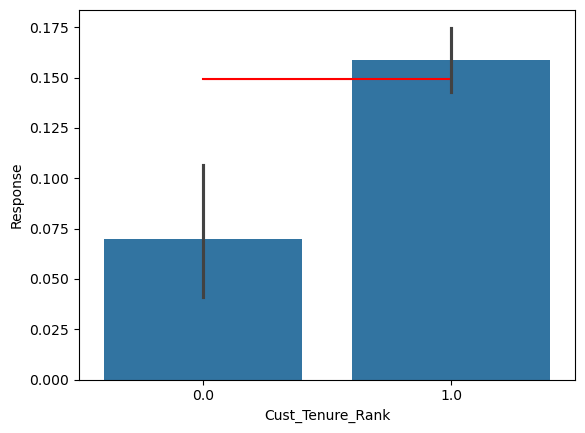

In [ ]:
X_bin_combined=pd.concat([Y,num_binned],axis=1,join='inner')

from numpy import mean
for col in (num_binned.columns):
    plt.figure()
    sns.lineplot(x=col,y=X_bin_combined['Response'].mean(),data=X_bin_combined,color='red')
    sns.barplot(x=col, y="Response",data=X_bin_combined, estimator=mean )
plt.show()

In [ ]:
feature_importance = {}

for col in num_binned.columns:
    # Calculate the average response rate for each bin in the column
    bin_means = X_bin_combined.groupby(col)['Response'].mean()

    # Calculate the gap between the highest-responding bin and the lowest
    max_diff = bin_means.max() - bin_means.min()
    feature_importance[col] = max_diff

importance_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Max_Response_Diff'])
importance_df = importance_df.sort_values(by='Max_Response_Diff', ascending=False).reset_index(drop=True)

print("Features ranked by predictive power (High gap = Keep, Low gap = Drop):")
print(importance_df)

Features ranked by predictive power (High gap = Keep, Low gap = Drop):
                     Feature  Max_Response_Diff
0       MntMeatProducts_Rank           0.371880
1              MntWines_Rank           0.357617
2                Income_Rank           0.294643
3   NumCatalogPurchases_Rank           0.266101
4     NumDealsPurchases_Rank           0.251247
5       NumWebPurchases_Rank           0.243228
6               Recency_Rank           0.237827
7          MntGoldProds_Rank           0.217559
8      MntSweetProducts_Rank           0.173351
9             MntFruits_Rank           0.170728
10    NumStorePurchases_Rank           0.157877
11      MntFishProducts_Rank           0.144737
12                  Age_Rank           0.111785
13    NumWebVisitsMonth_Rank           0.110117
14          Cust_Tenure_Rank           0.089146


based on these results it does not seem like age, cust_tenure, and numvisits month really correlates to response rate so let's remove it

In [ ]:
num_droplist = ['Age', 'Cust_Tenure','NumWebVisitsMonth']
num_2 = num_2.drop(num_droplist,axis = 1)
num_2.shape

(2240, 12)

### Select the k best features

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
# just randomly picking k = 8 but I could change
k_best_num = SelectKBest(score_func=f_classif, k=10)

k_best_num.fit(num_2, Y)

# Get the names of the top features it chose
top_num_features = num_2.columns[k_best_num.get_support()].tolist()

# Let's make a clean table to see the actual scores for every single column
num_scores = pd.DataFrame({
    'Feature': num_2.columns,
    'F_Score': k_best_num.scores_
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print(f"--- The Top {k_best_num.k} Numerical Features ---")
print(top_num_features)
print("\n--- The Full Mathematical Rankings ---")
print(num_scores)

--- The Top 10 Numerical Features ---
['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumCatalogPurchases']

--- The Full Mathematical Rankings ---
                Feature     F_Score
0       MntMeatProducts  146.524338
1              MntWines  142.798305
2   NumCatalogPurchases  134.062237
3               Recency   91.759828
4                Income   65.191278
5       NumWebPurchases   59.183898
6          MntGoldProds   47.092658
7             MntFruits   36.276161
8      MntSweetProducts   32.471869
9       MntFishProducts   28.826618
10    NumStorePurchases    3.153801
11    NumDealsPurchases    0.086872


After this analysis think ill change k to 9 since they are still providing valuable insights, and ill drop the other two

In [ ]:
# Drop the statistically useless features
features_to_drop = ['NumStorePurchases', 'NumDealsPurchases']
num_2_final = num_2.drop(columns=features_to_drop)

print(f"Final number of numerical features: {num_2_final.shape[1]}")

Final number of numerical features: 10


## Now let's focus on the categorical features and our feature selection

In [ ]:
X_cat.dtypes

Education         object
Marital_Status    object
Kidhome           object
Teenhome          object
AcceptedCmp3      object
AcceptedCmp4      object
AcceptedCmp5      object
AcceptedCmp1      object
AcceptedCmp2      object
Complain          object
Z_CostContact     object
Z_Revenue         object
dtype: object

In [ ]:
# 1. Quick overview: How many unique values does each column have?
print("--- Number of Unique Values per Column ---")
print(X_cat.nunique().sort_values(ascending=False))


--- Number of Unique Values per Column ---
Marital_Status    8
Education         5
Kidhome           3
Teenhome          3
AcceptedCmp3      2
AcceptedCmp4      2
AcceptedCmp5      2
AcceptedCmp1      2
AcceptedCmp2      2
Complain          2
Z_CostContact     1
Z_Revenue         1
dtype: int64


REMOVE Z ones since not valuable

In [ ]:

useless_cols = ['Z_CostContact', 'Z_Revenue']

# Drop them from the categorical dataframe
X_cat = X_cat.drop(columns=useless_cols, errors='ignore')

In [ ]:
print(X_cat.nunique().sort_values(ascending=False))

Marital_Status    8
Education         5
Kidhome           3
Teenhome          3
AcceptedCmp3      2
AcceptedCmp4      2
AcceptedCmp5      2
AcceptedCmp1      2
AcceptedCmp2      2
Complain          2
dtype: int64


### Bi-Variate Analysis

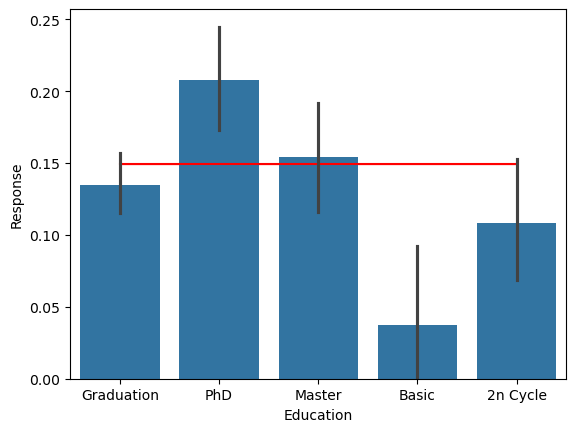

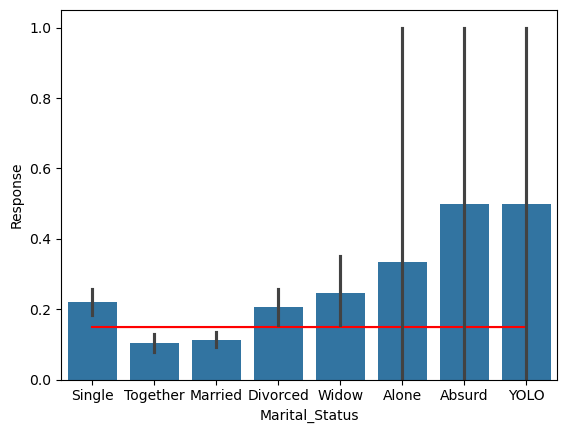

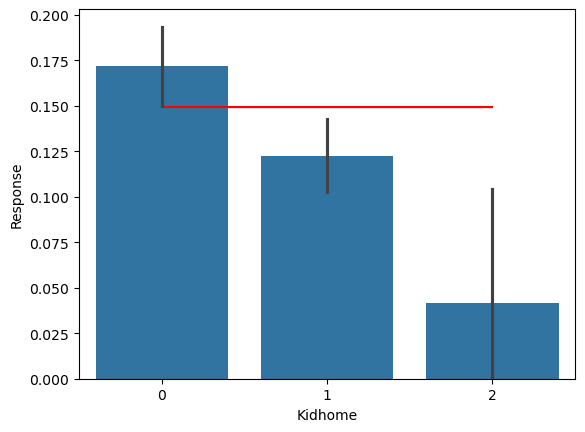

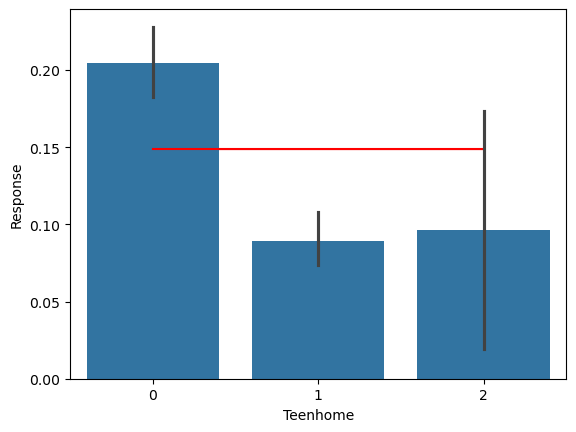

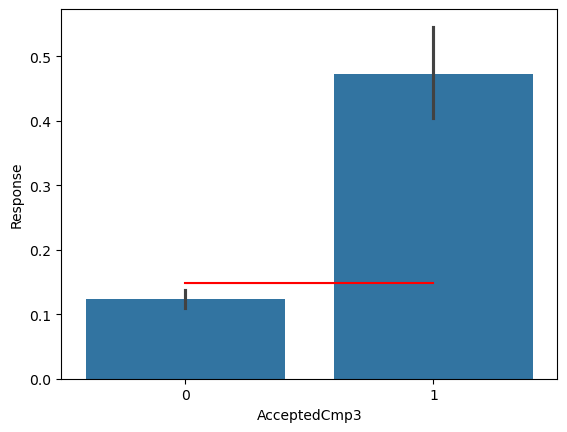

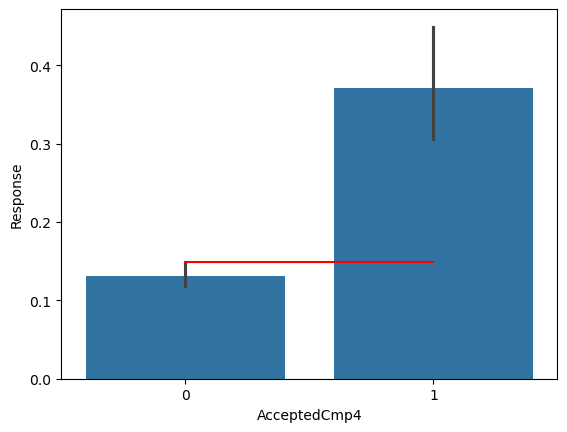

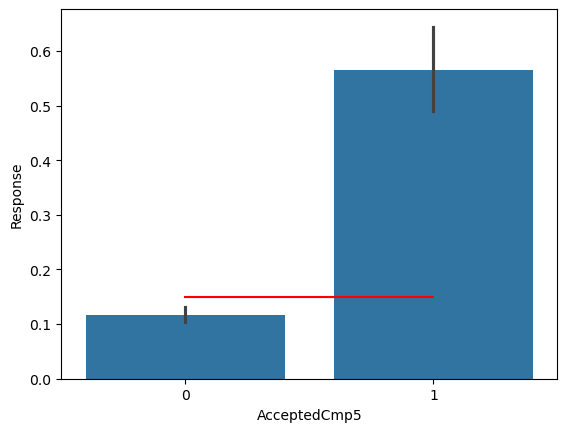

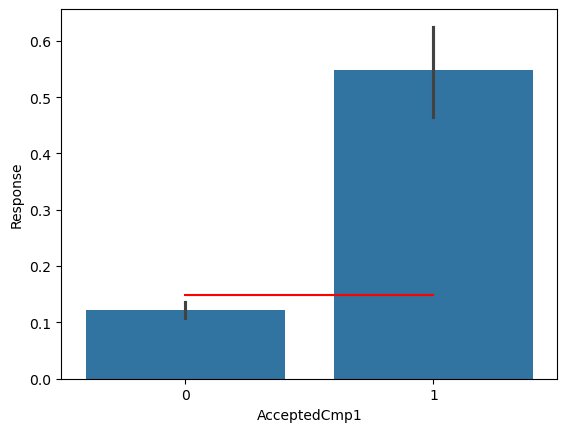

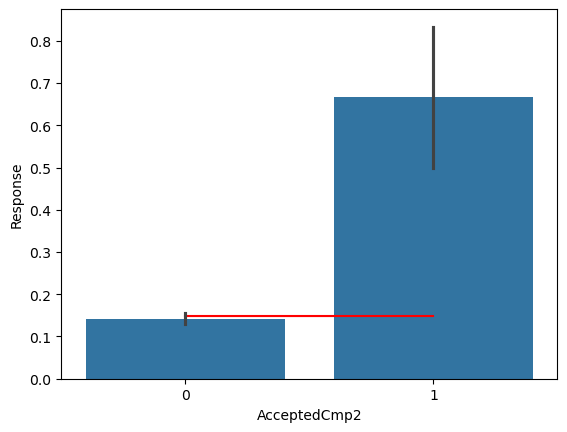

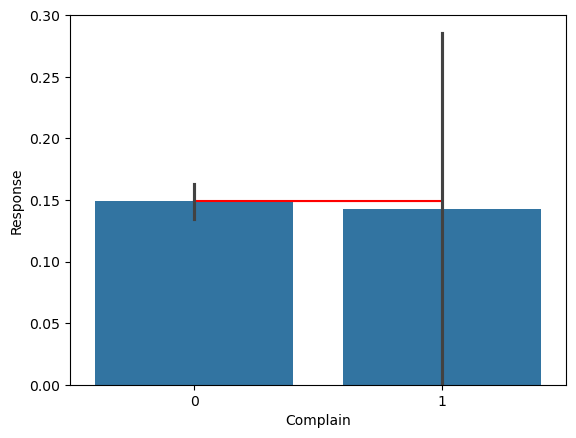

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
X_cat_merged=pd.concat([Y,X_cat],axis=1,join='inner')

from numpy import mean
for col in (X_cat.columns):
    plt.figure()
    sns.lineplot(x=col,y=X_cat_merged['Response'].mean(),data=X_cat_merged,color='red')
    sns.barplot(x=col, y="Response",data=X_cat_merged, estimator=mean )
plt.show()

In [ ]:
cat_importance = {}

for col in X_cat.columns:
    # Calculate the average response rate for each group in the category
    cat_means = X_cat_merged.groupby(col)['Response'].mean()

    # Calculate the gap between the highest-responding group and the lowest
    max_diff = cat_means.max() - cat_means.min()
    cat_importance[col] = max_diff

# Convert to a clean, sorted table
cat_importance_df = pd.DataFrame(list(cat_importance.items()), columns=['Feature', 'Max_Response_Diff'])
cat_importance_df = cat_importance_df.sort_values(by='Max_Response_Diff', ascending=False).reset_index(drop=True)

print("Categorical Features ranked by gap (High gap = Keep, Low gap = Drop):")
print(cat_importance_df)

Categorical Features ranked by gap (High gap = Keep, Low gap = Drop):
          Feature  Max_Response_Diff
0    AcceptedCmp2           0.524585
1    AcceptedCmp5           0.447903
2    AcceptedCmp1           0.426951
3  Marital_Status           0.396552
4    AcceptedCmp3           0.348656
5    AcceptedCmp4           0.240047
6       Education           0.170782
7         Kidhome           0.130027
8        Teenhome           0.115343
9        Complain           0.006309


Dropping the complain seems useless

In [ ]:
# Drop the statistically useless category
X_cat = X_cat.drop(columns=['Complain'], errors='ignore')

print(f"Final number of categorical features: {X_cat.shape[1]}")

Final number of categorical features: 9


In [ ]:
# Create dummy features with n-1 levels
X_cat_dum = pd.get_dummies(X_cat, drop_first = True)
X_cat_dum.shape

(2240, 20)

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

k_best_cat = SelectKBest(score_func=chi2, k=15)

k_best_cat.fit(X_cat_dum, Y)

# Get the exact names of the winning categorical features
top_cat_features = X_cat_dum.columns[k_best_cat.get_support()].tolist()

# Create a clean dataframe that ONLY has the winning dummy columns
X_cat_final = X_cat_dum[top_cat_features]

cat_scores = pd.DataFrame({
    'Feature': X_cat_dum.columns,
    'Chi2_Score': k_best_cat.scores_
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("--- The Top Categorical Dummies (Chi-Square) ---")
print(cat_scores.head(15))

--- The Top Categorical Dummies (Chi-Square) ---
                    Feature  Chi2_Score
0            AcceptedCmp5_1  221.594577
1            AcceptedCmp1_1  181.147090
2            AcceptedCmp3_1  134.272389
3            AcceptedCmp4_1   64.958669
4            AcceptedCmp2_1   63.338611
5                Teenhome_1   29.018426
6     Marital_Status_Single   19.463612
7             Education_PhD   13.204244
8   Marital_Status_Together    9.530264
9    Marital_Status_Married    8.670013
10  Marital_Status_Divorced    6.106764
11     Marital_Status_Widow    5.786650
12          Education_Basic    5.345644
13                Kidhome_1    5.069912
14                Kidhome_2    4.367207


In [ ]:
X_master = pd.concat([num_2_final, X_cat_final], axis=1)

print(X_master.shape)
X_master.head()

(2240, 25)


,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,Education_Basic,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Kidhome_1,Kidhome_2,Teenhome_1,AcceptedCmp3_1,AcceptedCmp4_1,AcceptedCmp5_1,AcceptedCmp1_1,AcceptedCmp2_1
0,58138.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,8.0,10.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,46344.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,1.0,1.0,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False
2,71613.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,8.0,2.0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,26646.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,0.0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False
4,58293.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,3.0,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False


## Dimensionality Reduction

This process identifies correlated features and groups them through variable clustering

In [ ]:
%pip install varclushi

In [ ]:
X_master = X_master.astype(float)

from varclushi import VarClusHi
vc = VarClusHi(X_master,maxeigval2 = 1, maxclus = None)
vc.varclus()

In [ ]:
vc.info

,Cluster,N_Vars,Eigval1,Eigval2,VarProp
0,0,4,2.503937,0.683260,0.625984
1,1,4,1.832339,0.887457,0.458085
2,2,3,1.414911,0.999202,0.471637
3,3,3,1.202824,0.998729,0.400941
4,4,2,1.048109,0.951891,0.524055
5,5,2,1.027920,0.972080,0.513960
6,6,7,3.869312,0.979126,0.552759


RS_Ratio is the measure of how perfectly a variable represents it's family, The lower the number the better

In [ ]:
check = vc.rsquare
check

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
0,0,MntFruits,0.686526,0.324739,0.464226
1,0,MntFishProducts,0.711155,0.351315,0.445277
2,0,MntSweetProducts,0.664532,0.329011,0.499961
3,0,MntGoldProds,0.441724,0.253728,0.748087
4,1,AcceptedCmp4_1,0.469687,0.061088,0.564817
5,1,AcceptedCmp5_1,0.548967,0.175588,0.547097
6,1,AcceptedCmp1_1,0.474009,0.128941,0.603853
7,1,AcceptedCmp2_1,0.339677,0.015264,0.670558
8,2,Recency,0.003710,0.000281,0.996570
9,2,Marital_Status_Married,0.706561,0.016875,0.298476


Ok so I have a decision to make if I want to further reduce it, but since ive only got 24 factors I think that it wont make sense to further reduce the scope of data but if not i'd do this

In [ ]:
# filter = check[check['RS_Ratio'] <= 0.5]
# filter.shape

In [ ]:
# final_features = filter['Variable']
# X_master = X_master[final_features]
# X_master.shape


In [ ]:
X_master

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,Education_Basic,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Kidhome_1,Kidhome_2,Teenhome_1,AcceptedCmp3_1,AcceptedCmp4_1,AcceptedCmp5_1,AcceptedCmp1_1,AcceptedCmp2_1
0,58138.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,8.0,10.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,46344.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,71613.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,8.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,26646.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,58293.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46.0,709.0,43.0,182.0,42.0,118.0,227.0,9.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2236,64014.0,56.0,406.0,0.0,30.0,0.0,0.0,8.0,8.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2237,56981.0,91.0,908.0,48.0,217.0,32.0,12.0,24.0,2.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2238,69245.0,8.0,428.0,30.0,214.0,80.0,30.0,61.0,6.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# Time for Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_master, Y, test_size = 0.20, random_state = 20)

In [ ]:
print("shape of training data" , X_train.shape)
print("shape of testing data" , X_test.shape)
print("Response Rate in Training Data" , y_train.mean())
print("Response Rate in Testing Data" , y_train.mean())

shape of training data (1792, 25)
shape of testing data (448, 25)
Response Rate in Training Data Response    0.147879
dtype: float64
Response Rate in Testing Data Response    0.147879
dtype: float64


### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(random_state = 20)
logreg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,20
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(criterion = 'gini', random_state = 20)

### Grid Search for Model Optimization

In [ ]:
# Min_Samples_Split starting from 5% of training base
from sklearn.model_selection import GridSearchCV
param_dist = {'max_depth': [3, 5, 6, 7], 'min_samples_split': [75,100,125,150] }
tree_grid = GridSearchCV(dtree, cv = 10, param_grid=param_dist,n_jobs = 3)
tree_grid.fit(X_train,y_train)
print('Best Parameters using grid search: \n', tree_grid.best_params_)

Best Parameters using grid search: 
 {'max_depth': 3, 'min_samples_split': 75}


In [ ]:
dtree=DecisionTreeClassifier(criterion='gini',random_state=20,max_depth=3,min_samples_split=75)
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,75
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,20
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(criterion='gini',random_state=20,max_depth=3,min_samples_split=75)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,75
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Gradien Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbm=GradientBoostingClassifier(criterion='squared_error',random_state=20,max_depth=3,min_samples_split=75)
gbm.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'squared_error'
,min_samples_split,75
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Let's evaluate all these Models

In [ ]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred_logreg=logreg.predict(X_test)
y_pred_tree=dtree.predict(X_test)
y_pred_rf=rf.predict(X_test)
y_pred_gbm=gbm.predict(X_test)

In [ ]:
print("Accuracy from Logistic Regression Model :",metrics.accuracy_score(y_test, y_pred_logreg))
print("Precision from Logistic Regression Model :",metrics.precision_score(y_test,y_pred_logreg))
print("Recall from Logistic Regression Model :",metrics.recall_score(y_test,y_pred_logreg))
print("f1_score from Logistic Regression Model :",metrics.f1_score(y_test,y_pred_logreg))
print("Area under ROC Curve from Logistic Regression Model :",metrics.roc_auc_score(y_test,y_pred_logreg))
print("Gini from the Logistic Regression Model :",2*metrics.roc_auc_score(y_test,y_pred_logreg)-1)

Accuracy from Logistic Regression Model : 0.8571428571428571
Precision from Logistic Regression Model : 0.6190476190476191
Recall from Logistic Regression Model : 0.18840579710144928
f1_score from Logistic Regression Model : 0.28888888888888886
Area under ROC Curve from Logistic Regression Model : 0.5836488088409622
Gini from the Logistic Regression Model : 0.1672976176819243


In [ ]:
print("Accuracy from Decision Tree Model :",metrics.accuracy_score(y_test, y_pred_tree))
print("Precision from Decision Tree Model :",metrics.precision_score(y_test,y_pred_tree))
print("Recall from Decision Tree Model :",metrics.recall_score(y_test,y_pred_tree))
print("f1_score from Decision Tree Model :",metrics.f1_score(y_test,y_pred_tree))
print("Area under ROC Curve from Decision Tree Model :",metrics.roc_auc_score(y_test,y_pred_tree))
print("Gini from the Decision Tree Model :",2*metrics.roc_auc_score(y_test,y_pred_tree)-1)

Accuracy from Decision Tree Model : 0.8883928571428571
Precision from Decision Tree Model : 0.8518518518518519
Recall from Decision Tree Model : 0.3333333333333333
f1_score from Decision Tree Model : 0.4791666666666667
Area under ROC Curve from Decision Tree Model : 0.6613896218117854
Gini from the Decision Tree Model : 0.3227792436235708


In [ ]:
print("Accuracy from Random Forest Model :",metrics.accuracy_score(y_test, y_pred_rf))
print("Precision from Random Forest Model :",metrics.precision_score(y_test,y_pred_rf))
print("Recall from Random Forest Model :",metrics.recall_score(y_test,y_pred_rf))
print("f1_score from Random Forest Model :",metrics.f1_score(y_test,y_pred_rf))
print("Area under ROC Curve from Random Forest Model :",metrics.roc_auc_score(y_test,y_pred_rf))
print("Gini from the Random Forest Model :",2*metrics.roc_auc_score(y_test,y_pred_rf)-1)

Accuracy from Random Forest Model : 0.8638392857142857
Precision from Random Forest Model : 1.0
Recall from Random Forest Model : 0.11594202898550725
f1_score from Random Forest Model : 0.2077922077922078
Area under ROC Curve from Random Forest Model : 0.5579710144927537
Gini from the Random Forest Model : 0.11594202898550732


In [ ]:
print("Accuracy from GBM Model :",metrics.accuracy_score(y_test, y_pred_gbm))
print("Precision from GBM Model :",metrics.precision_score(y_test,y_pred_gbm))
print("Recall from GBM Model :",metrics.recall_score(y_test,y_pred_gbm))
print("f1_score from GBM Model :",metrics.f1_score(y_test,y_pred_gbm))
print("Area under ROC Curve from GBM Model :",metrics.roc_auc_score(y_test,y_pred_gbm))
print("Gini from the GBM Model :",2*metrics.roc_auc_score(y_test,y_pred_gbm)-1)

Accuracy from GBM Model : 0.8772321428571429
Precision from GBM Model : 0.7333333333333333
Recall from GBM Model : 0.3188405797101449
f1_score from GBM Model : 0.4444444444444444
Area under ROC Curve from GBM Model : 0.64886620014531
Gini from the GBM Model : 0.2977324002906201


#### Ok so looking at these results I should prioritize it seems like the Grid Search is providing the best data
Recall (0.318): The GBM found almost 3x as many actual buyers as the Random Forest (31.8% vs 11.5%).

Precision (0.733): Even though it took more risks to find those buyers, it still maintained a very strong 73% hit rate when it guessed "Yes".

F1-Score (0.44 vs 0.20): Because F1 is the mathematical balance between Precision and Recall, the GBM's score completely obliterates the Random Forest here.

### Ok now it's time for Grid Search to do some parameter testing to find the best possible outcome

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# 1. Define the grid of settings we want to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Try 50, 100, and 200 trees
    'learning_rate': [0.01, 0.1, 0.2],   # Try slow, medium, and fast learning
    'max_depth': [3, 4, 5]               # Try shallow, medium, and deep trees
}

# 2. Initialize the Grid Search
# cv=5 means it will cross-validate the results 5 times to be absolutely sure
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1 # This prints out a progress bar so you aren't left guessing!
)

# 3. Unleash it on your training data!
print("Starting Grid Search... this might take a minute depending on your computer's speed!")
grid_search.fit(X_train, y_train.values.ravel())

# 4. Print the absolute best settings it found
print("\n--- Grid Search Complete ---")
print("Best Parameters Found:", grid_search.best_params_)
print("Best AUC Score from Grid Search:", grid_search.best_score_)

Starting Grid Search... this might take a minute depending on your computer's speed!
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Grid Search Complete ---
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best AUC Score from Grid Search: 0.8590529243968955


## Extracting Feature importance from the GBM

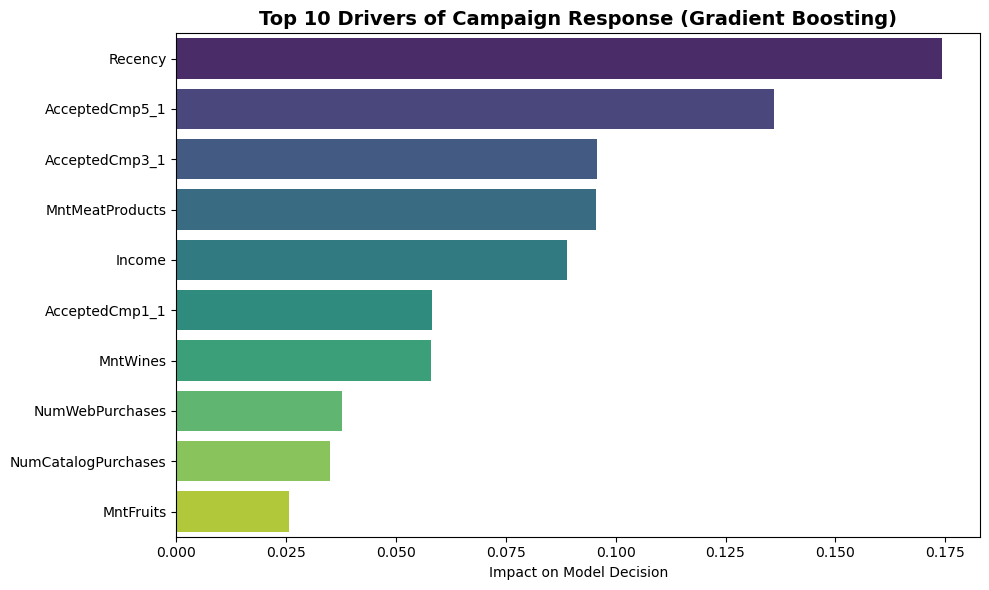

In [ ]:
best_gbm = grid_search.best_estimator_
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Campaign Response (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.xlabel('Impact on Model Decision')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Probability Decile Analysis and Gain Chart/Lorenz Curve

This will split our model into 10 perfectly equal groups, Decile 1 is the top 10% of our highest scoring customers and Decile 10 is the bottom 10%, it then checks how many of actual buyers ended up in each one of those 10 splits, theoretically the top couple of deciles should have the majority of the buyers and then we can focus the ad campaign on these buckets of people rather than sending out an ad campaign to everyone we can limit our scope to high likelihood candidates

In [ ]:
# 1. Get the decimal probabilities for the 20% test data
y_prob = best_gbm.predict_proba(X_test)[:, 1]

decile_df = pd.DataFrame({'Actual_Result': y_test.values.ravel(), 'Probability': y_prob})

# 3. Sort from highest probability to lowest
decile_df = decile_df.sort_values(by='Probability', ascending=False)

# 4. Chop into 10 equal buckets (Deciles) using pandas qcut
decile_df['Decile'] = pd.qcut(decile_df['Probability'].rank(method='first'), 10, labels=False)
decile_df['Decile'] = 10 - decile_df['Decile']

# 5. Calculate the business metrics per decile
decile_report = decile_df.groupby('Decile').agg(
    Customers_Contacted=('Actual_Result', 'count'),
    Actual_Buyers_Found=('Actual_Result', 'sum'),
    Min_Prob_Score=('Probability', 'min'),
    Max_Prob_Score=('Probability', 'max')
).reset_index()

decile_report['Decile_Response_Rate'] = (decile_report['Actual_Buyers_Found'] / decile_report['Customers_Contacted']).map("{:.1%}".format)
decile_report['Cumulative_Buyers'] = decile_report['Actual_Buyers_Found'].cumsum()

total_buyers = decile_report['Actual_Buyers_Found'].sum()
decile_report['%_of_Total_Buyers_Captured'] = (decile_report['Cumulative_Buyers'] / total_buyers).map("{:.1%}".format)

print("--- Executive ROI Report: Probability Deciles ---")
display(decile_report)

--- Executive ROI Report: Probability Deciles ---


,Decile,Customers_Contacted,Actual_Buyers_Found,Min_Prob_Score,Max_Prob_Score,Decile_Response_Rate,Cumulative_Buyers,%_of_Total_Buyers_Captured
0,1,45,31,0.471452,0.943105,68.9%,31,44.9%
1,2,45,17,0.205608,0.453589,37.8%,48,69.6%
2,3,45,10,0.127154,0.191627,22.2%,58,84.1%
3,4,44,4,0.089805,0.126316,9.1%,62,89.9%
4,5,45,2,0.061337,0.089803,4.4%,64,92.8%
5,6,45,3,0.045187,0.061320,6.7%,67,97.1%
6,7,44,0,0.034610,0.045031,0.0%,67,97.1%
7,8,45,0,0.027829,0.034512,0.0%,67,97.1%
8,9,45,2,0.020970,0.027551,4.4%,69,100.0%
9,10,45,0,0.008074,0.020785,0.0%,69,100.0%


ok so analyzing this data, the first decile we contacted only 45 customers and we found 31 acutal buyers , which is close to 70% response rate which I imagine is much higher, and if we look the deciles from 5-10 had pretty bad results which means that our model worked really well and we can focus on the individuals in the top deciles for our ad campaign instead of focusing on sending it to everyone, saving us money on our campaign

If we picked the top 30% of our customers from this model we would find 84.1% of the buyers total which is pretty substantial

# What Does this Actually mean

### Key Drivers: The model identified that past campaign acceptance, income levels, and specific purchasing habits are the strongest indicators of a buyer.

### The Business Impact (ROI):
### By running a Probability Decile Analysis on the model's predictions, I have identified a massive cost-saving opportunity:

### The "Sweet Spot": If we exclusively target the top 30% of our customer base (Deciles 1-3), we will successfully capture 84.1% of all projected buyers.

### The Savings: This allows us to cut our marketing outreach costs by 70%, while simultaneously reducing unsubscribe rates by suppressing the bottom 40% of customers who the model identified as highly unlikely to respond.

### The Lift: This predictive targeting is 2.8x more effective than random or basic demographic guessing.